In [1]:
from qiskit import QuantumCircuit

C:\Users\EricChatterjee2\AppData\Local\Temp\ipykernel_93388\3957343935.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


In [2]:
from qiskit.quantum_info import Operator

In [3]:
from qiskit.quantum_info import Statevector

In [4]:
import numpy as np

In [5]:
import matplotlib as mpl

In [6]:
n = 8

In [7]:
m = int(np.ceil(np.log(n)/np.log(2)))

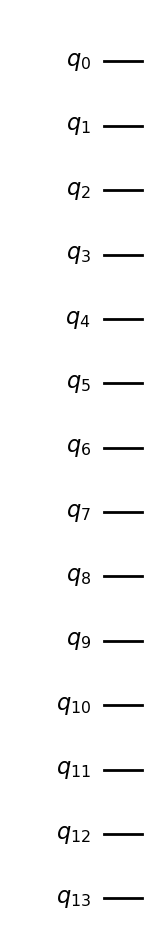

In [8]:
qc = QuantumCircuit(n+m+3)

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [9]:
state.draw('latex')

<IPython.core.display.Latex object>

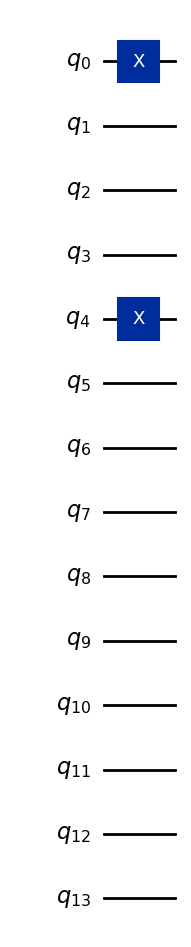

In [10]:
# Setting up the initial n-site state

qc.x(0) # 0th site is excited
qc.x(4) # 4th site is excited

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [11]:
state.draw('latex')

<IPython.core.display.Latex object>

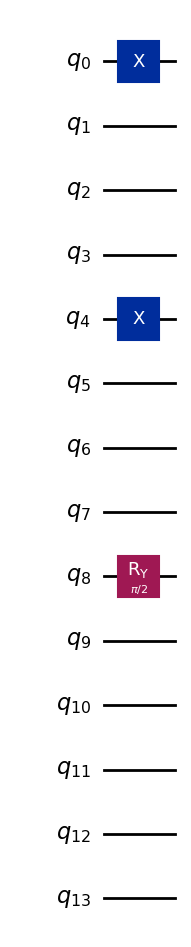

In [12]:
# Using the rightmost 2 auxiliary bits to represent string category

w = 10**10 # self-energy of each site
g = 5*10**9 # site-site coupling

theta = np.arccos(np.sqrt(w/(w + 2*g))) # desired rotation angle for rightmost bit

qc.ry(2*theta,n)

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [13]:
state.draw('latex')

<IPython.core.display.Latex object>

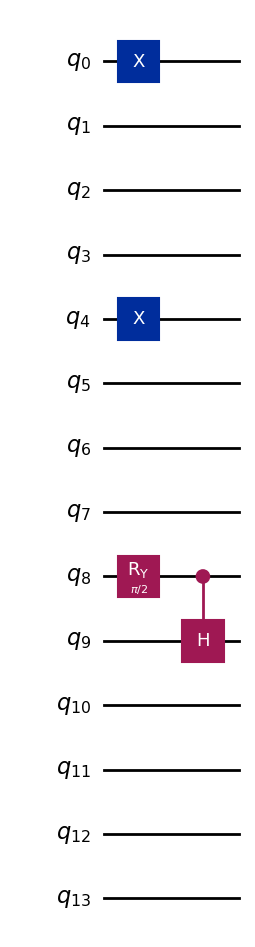

In [14]:
qc.ch(n,n+1)

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [15]:
state.draw('latex')

<IPython.core.display.Latex object>

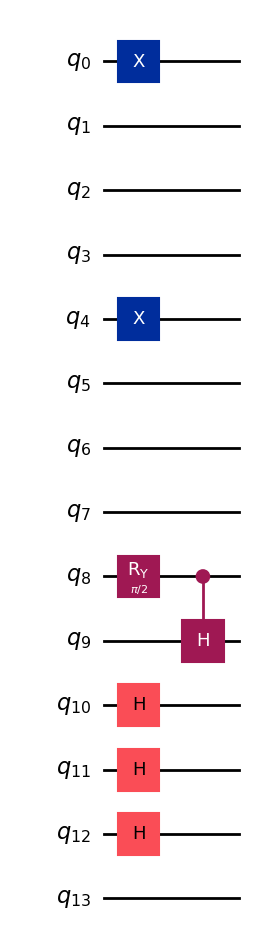

In [16]:
# Establishing individual strings for each category of strings by applying Hadamard on all ancillary bits that mark individual
# sites (i.e., n+2 through n+m+1)

qc.h(range(n+2,n+m+2))

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [17]:
state.draw('latex')

<IPython.core.display.Latex object>

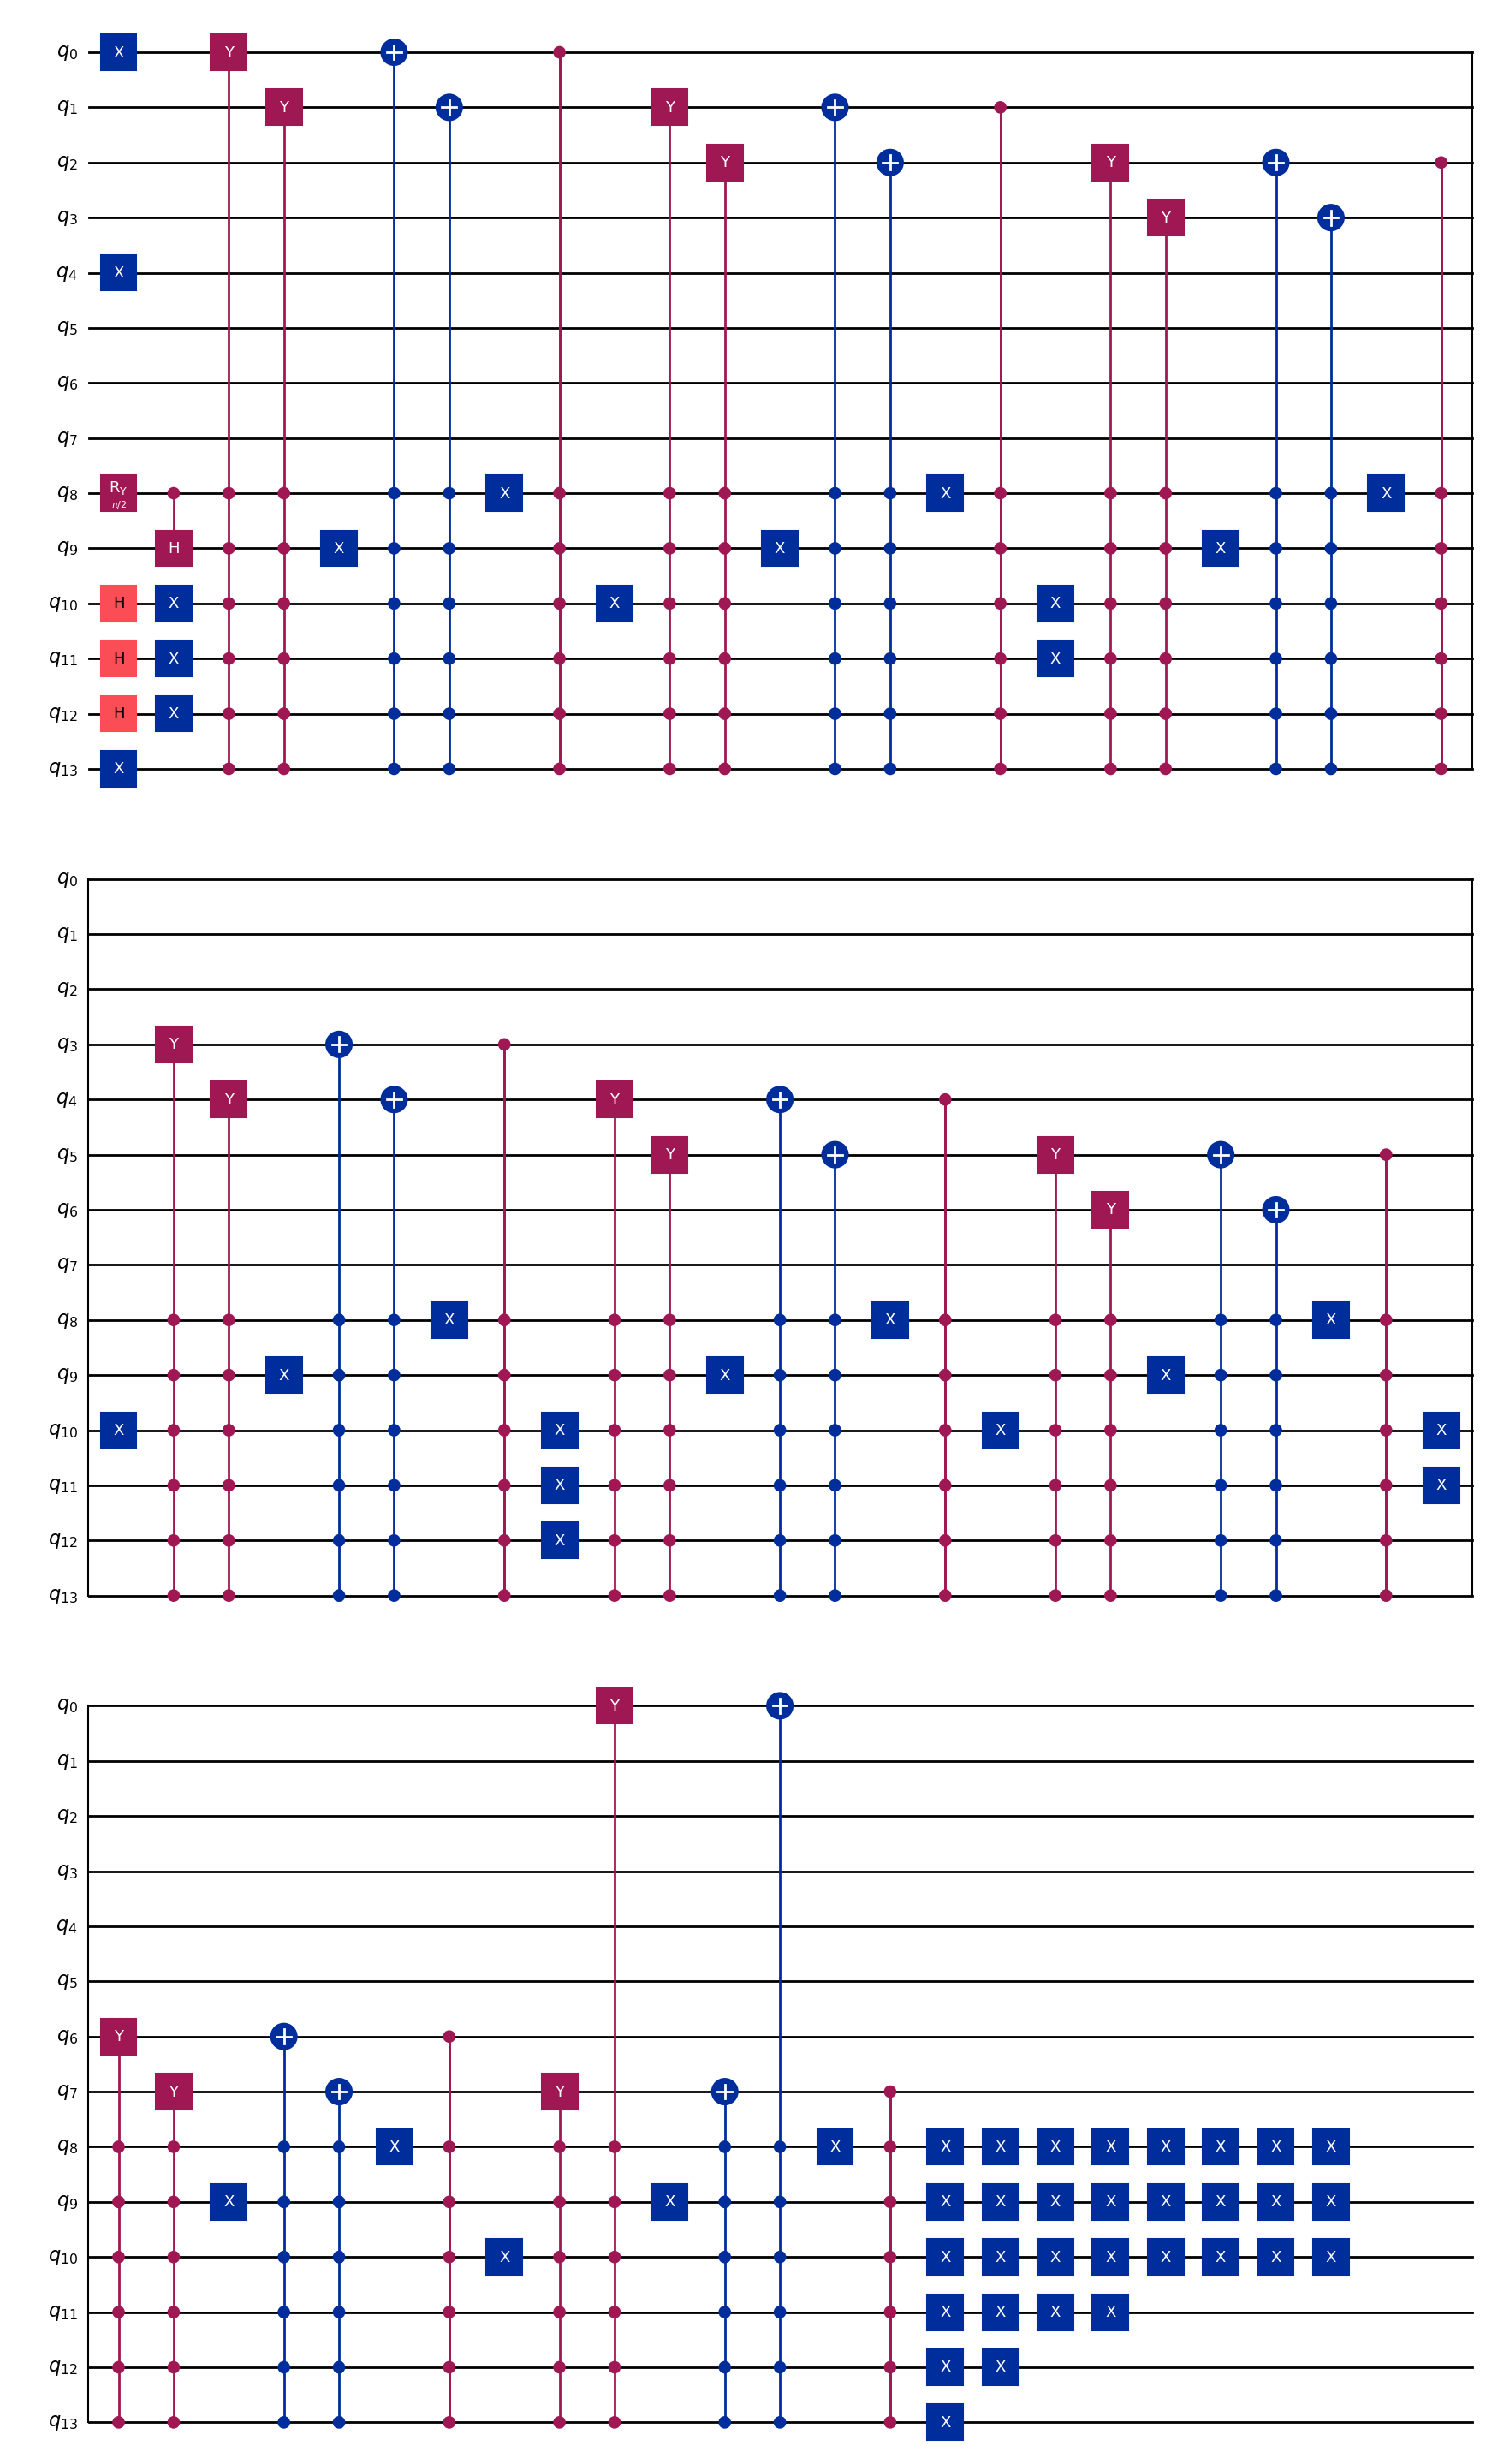

In [18]:
# We have now applied the PREP operator. The next step is to apply SELECT. Here, we use the leftmost ancillary bit to create
# the matrix of the form [U, 0; 0, I] by applying anti-controlled-U on all bits except the leftmost bit, conditioned on the 
# leftmost bit. This can be achieved by first applying an X gate to the leftmost bit:

qc.x(n+m+2)

# Now, we apply the SELECT operator U on the data bits. Note that U is a block-diagonal matrix of the Pauli strings. Since each
# set of ancillary bits corresponds to a unique Pauli string, our goal is to apply controlled-Pauli-strings targeting the data
# bits conditioned on the ancillary bit combination. We thus run a for loop over all possible ancillary bit combinations to
# switch each of them individually to all 1s so that we can use the multi-controlled Pauli operators:

from qiskit.circuit.library import MCXGate
from qiskit.circuit.library import YGate
from qiskit.circuit.library import ZGate

mcy_gate = YGate().control(m+3)
mcz_gate = ZGate().control(m+3)

control_qubits = range(n,n+m+3)

for site in range(n-1): # This is not n, because we separately consider the (n-1)^st site and its coupling with the 0^th site
    
    for k in range(m):
        if np.mod(site,2**k) == 0:
            qc.x(n+2+k) # Maps m-bit ancillas marking the site to all 1s
    
    qc.append(mcy_gate,list(control_qubits) + [site]) # For the rightmost 2 ancillas, 11 represents the Y Pauli string category
    qc.append(mcy_gate,list(control_qubits) + [site+1])
    
    qc.x(n+1) # Mapping 01 (corresponding to the X Pauli string category) to 11 for the rightmost 2 ancillas
    
    qc.mcx(list(control_qubits),site)
    qc.mcx(list(control_qubits),site+1)
    
    qc.x(n) # Together with previous X gate, these map 00 (corresponding to the Z Pauli string category) to 11
    
    qc.append(mcz_gate,list(control_qubits) + [site])
    
# Now, we handle the n^{th} site

for site in range(n-1,n):
    
    for k in range(m):
        if np.mod(site,2**k) == 0:
            qc.x(n+2+k)
    
    qc.append(mcy_gate,list(control_qubits) + [site])
    qc.append(mcy_gate,list(control_qubits) + [0]) # Since the next site after n-1 is 0, not n
    
    qc.x(n+1)
    
    qc.mcx(list(control_qubits),site)
    qc.mcx(list(control_qubits),0)
    
    qc.x(n)
    
    qc.append(mcz_gate,list(control_qubits) + [site])
    
# Finally, we revert the ancillas by running the bit flips in reverse.

for site in range(n):
    for k in range(m):
        if np.mod(site,2**k) == 0:
            qc.x(n+2+k) # Reverts the m-bit register
    qc.x(n+1) # This and the next operation revert the rightmost 2 ancillas
    qc.x(n)
    
qc.x(n+m+2) # Reverting the lefmost ancilla

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [19]:
state.draw('latex')

<IPython.core.display.Latex object>

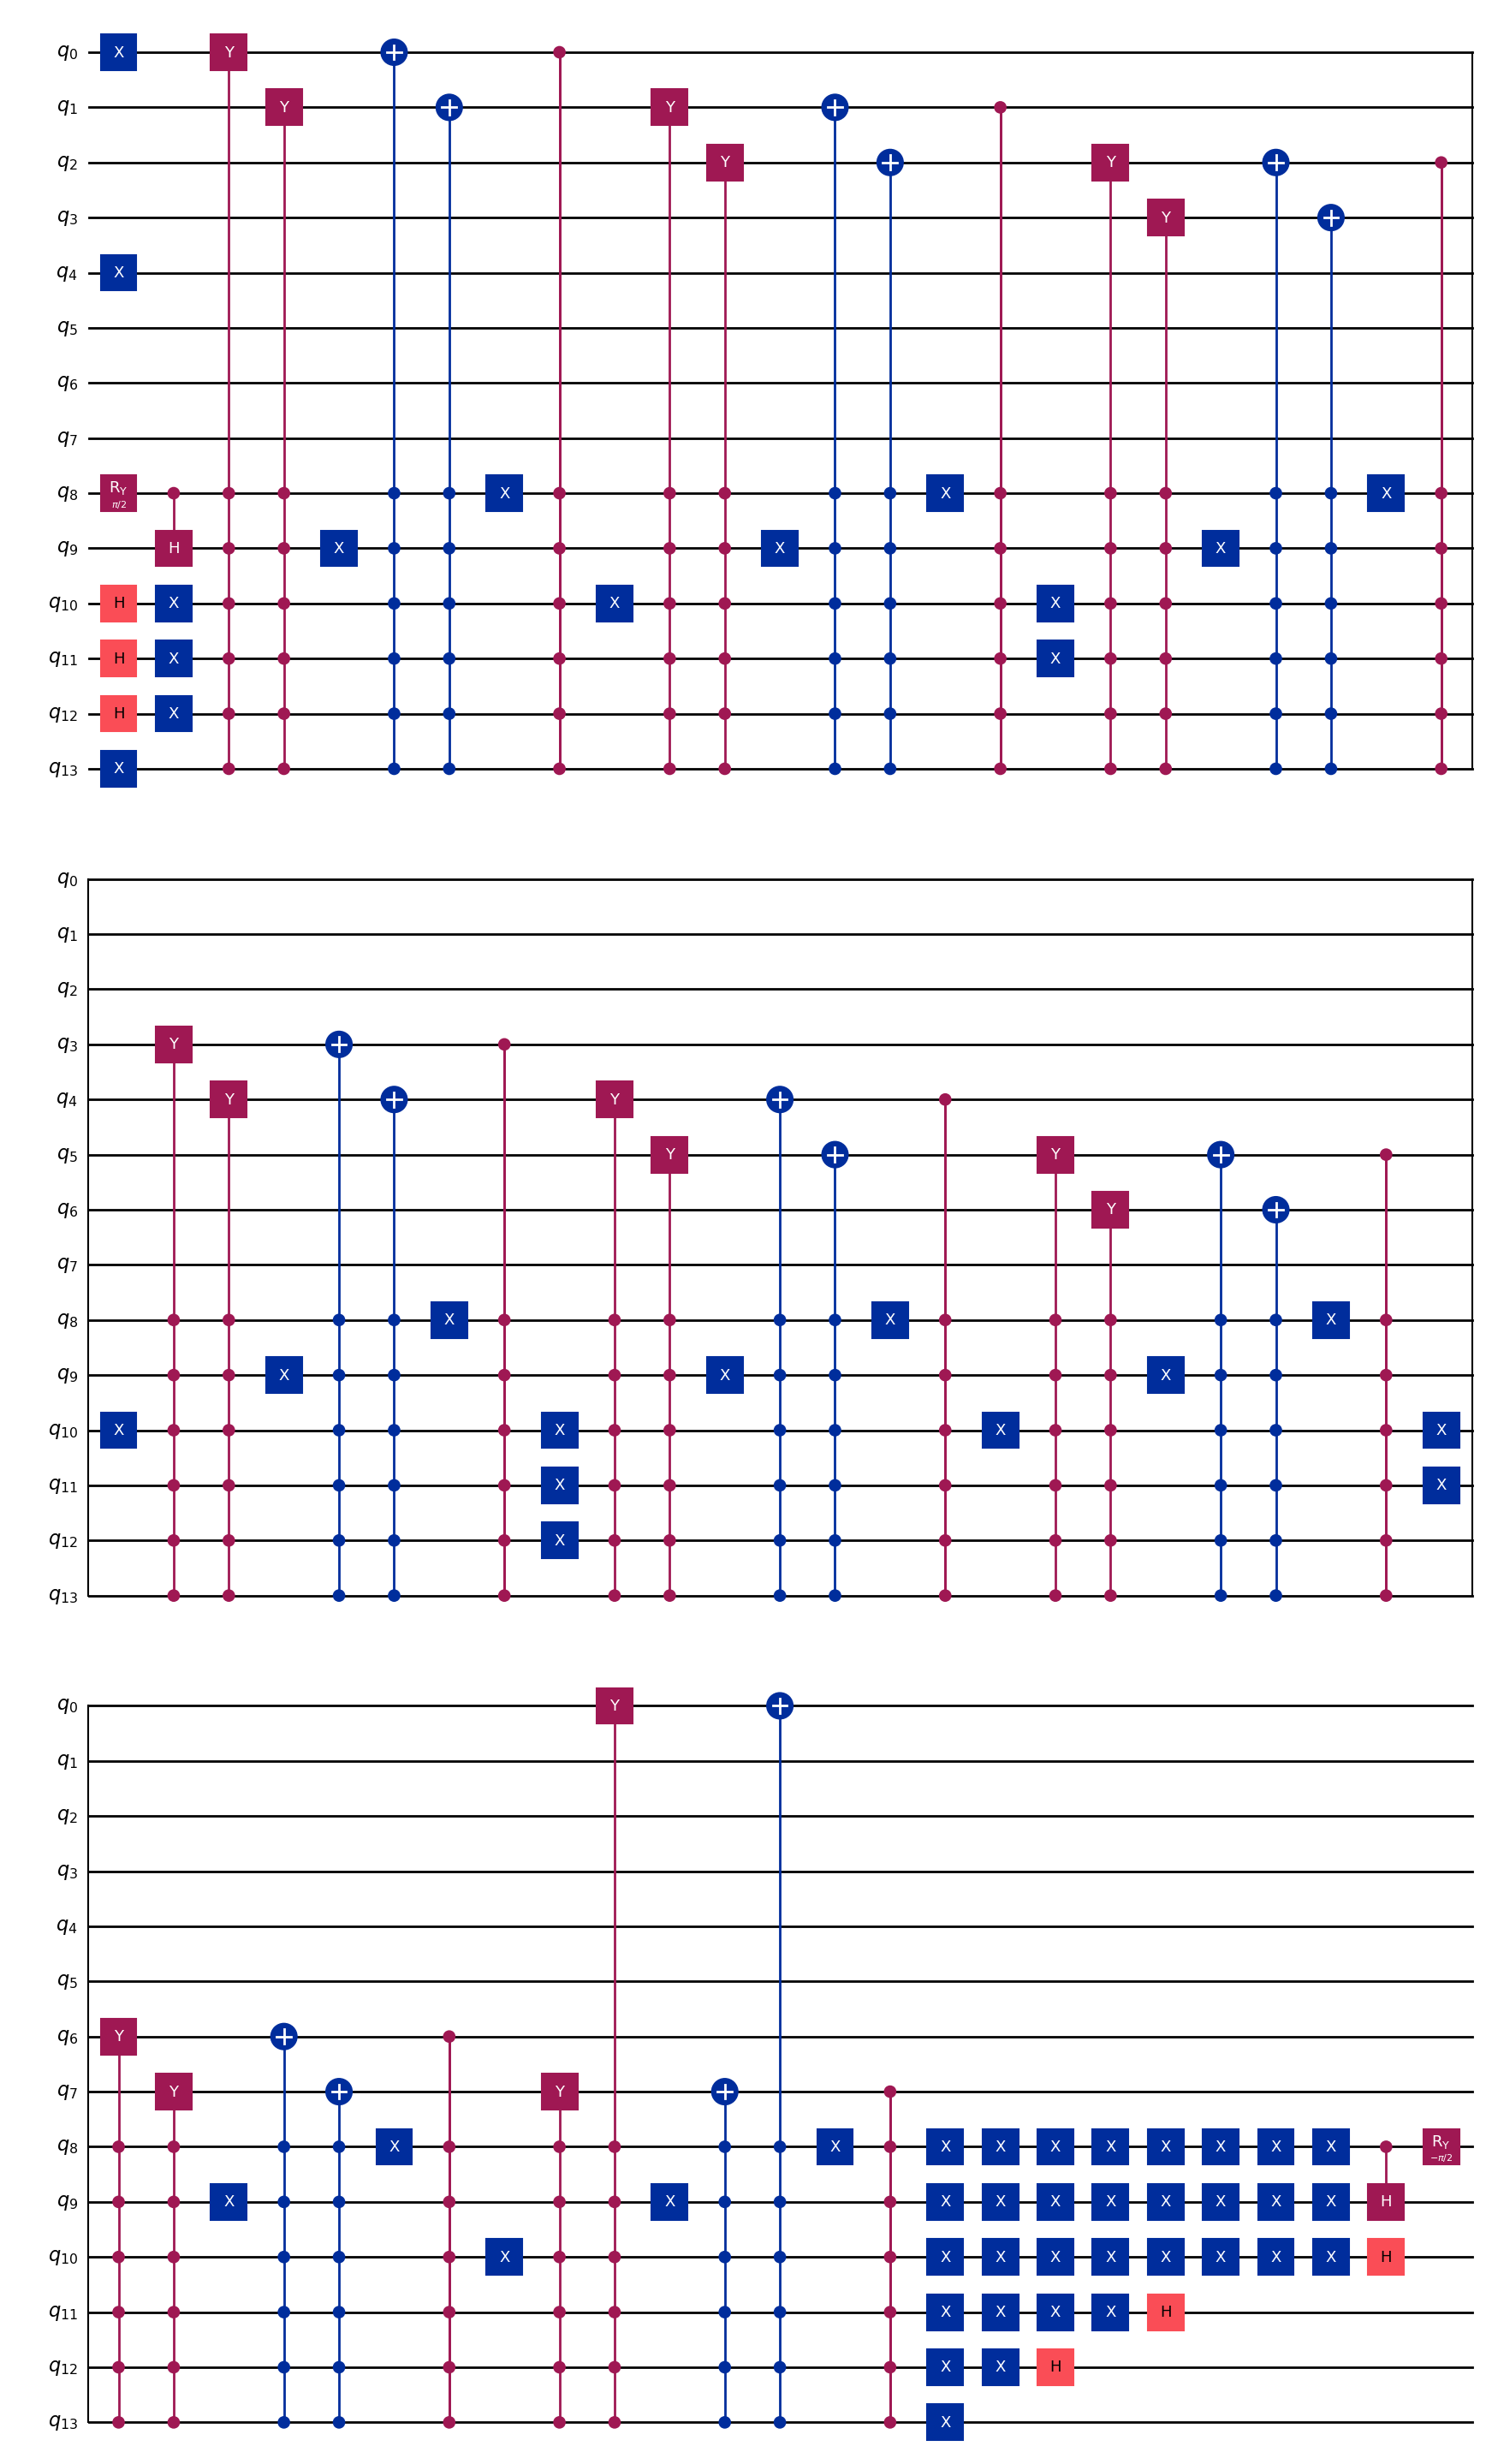

In [20]:
# Next, we apply PREP^{\dag} by reversing the steps in PREP and specifically changing the R_Y(2*\theta) to R_Y(-2*\theta)

qc.h(range(n+2,n+m+2))

qc.ch(n,n+1)

qc.ry(-2*theta,n)

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [21]:
state.draw('latex')

<IPython.core.display.Latex object>

In [22]:
# Having block-encoded the Hamiltonian (scaled by a coefficient \alpha), we now use GQSP to obtain the block-encoding for the 
# propagator e^{-iHt} = e^{-i(H/\alpha)(\alpha*t)}. The Jacobi-Anger expansion of this propagator is:

# e^{-i*x*\alpha*t} = J_0(\alpha*t) + 2 \sum_{k = 1}^{\infty} (-i)^k J_k(\alpha*t) T_k(x),

# where x represents each eigenvalue of H/\alpha, and the J and T functions are Bessel and Chebyshev functions of the first
# kind, respectively. We first analytically expand the Chebyshev functions. Here, T_0(x) = 1, T_1(x) = x, and for any higher
# order, T_{n+1}(x) = 2xT_n(x) - T_{n-1}(x). If we expand the propagator to polynomial power d, we can express the coefficients
# of the power expansion for each T using a (d+1)-element array.

d = 6

t = {}

t[0] = np.array([1] + [0]*d)
t[1] = np.array([0] + [1] + [0]*(d-1))

for n in range(2,d+1):
    t[n] = np.array([0]*(d+1)) # Initializing for each n
    t[n][0] = -t[n-2][0] # Special case for i = 0, since t[n-1][m-1] does not exist for this case
    for i in range(1,d+1):
        t[n][i] = 2*t[n-1][i-1] - t[n-2][i]

In [23]:
t

{0: array([1, 0, 0, 0, 0, 0, 0]),
 1: array([0, 1, 0, 0, 0, 0, 0]),
 2: array([-1,  0,  2,  0,  0,  0,  0]),
 3: array([ 0, -3,  0,  4,  0,  0,  0]),
 4: array([ 1,  0, -8,  0,  8,  0,  0]),
 5: array([  0,   5,   0, -20,   0,  16,   0]),
 6: array([ -1,   0,  18,   0, -48,   0,  32])}

In [24]:
# Substituting this in the Jacobi-Anger polynomial expansion:

import scipy as sp

tau = 0.1 # represents \alpha*t (this is a sample value)

pxhold = {}

pxhold[0] = np.array([sp.special.jv(0,tau)] + [0]*d)

for n in range(1,d+1):
    pxhold[n] = 2*(-1j)**n*sp.special.jv(n,tau)*t[n]
    
px = sum(pxhold[n] for n in range(d+1))

In [25]:
px

array([ 1.00000000e+00+0.00000000e+00j,  0.00000000e+00-1.00000000e-01j,
       -5.00000000e-03+0.00000000e+00j,  0.00000000e+00+1.66666649e-04j,
        4.16666636e-06+0.00000000e+00j,  0.00000000e+00-8.32986173e-08j,
       -1.38839293e-09+0.00000000e+00j])

In [26]:
# Converting from P(x) to P(z):

pzhold = {}

# Starting with only non-negative values:

pzraw = np.zeros(d+1, dtype=complex)

for k in range(d+1):
    pzhold[k] = np.zeros(d+1, dtype=complex) # Initializing for each k
    for i in range(int(np.floor((d-k)/2))+1): # the maximum m is (d-k)/2 ((d-k-1)/2), if d and k have same (opposite) parities
        pzhold[k][i] = 1/2**(k+2*i)*sp.special.factorial(k+2*i)/(sp.special.factorial(i)*sp.special.factorial(k+i))*px[k+2*i]
    pzraw[k] = sum(pzhold[k][i] for i in range(int(np.floor((d-k)/2))+1))
    
# Expanding to include negative k values (by symmetry P_{-k}(z) = P_k(z)) and shift from [-d,d] to [0,2d]:

pz = np.zeros(2*d+1, dtype=complex)

for kprime in range(d):
    k = kprime - d
    pz[kprime] = pzraw[-k]
    
for kprime in range(d,2*d+1):
    k = kprime - d
    pz[kprime] = pzraw[k]    

In [27]:
pz

array([-2.16936396e-11+0.00000000e+00j,  0.00000000e+00-2.60308179e-09j,
        2.60286485e-07+0.00000000e+00j,  0.00000000e+00+2.08203158e-05j,
       -1.24895866e-03+0.00000000e+00j,  0.00000000e+00-4.99375260e-02j,
        9.97501562e-01+0.00000000e+00j,  0.00000000e+00-4.99375260e-02j,
       -1.24895866e-03+0.00000000e+00j,  0.00000000e+00+2.08203158e-05j,
        2.60286485e-07+0.00000000e+00j,  0.00000000e+00-2.60308179e-09j,
       -2.16936396e-11+0.00000000e+00j])

In [28]:
# Now that we have the P(z) values, we solve for Q(z) using the GQSP code:

import torch
from torch.nn.functional import conv1d, pad
from torch.fft import fft
from torchaudio.transforms import Convolve, FFTConvolve
import time
import numpy as np

# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xarray = np.random.uniform(-0.1,0.1,4*d+2) # needs to be twice the size of P
x = torch.from_numpy(xarray)

def objective_torch(x, P):
    x.requires_grad = True

    real_part = x[:len(x) // 2]
    imag_part = x[len(x) // 2:]

    real_flip = torch.flip(real_part, dims=[0])
    imag_flip = torch.flip(-1*imag_part, dims=[0])

    conv_real_part = FFTConvolve("full").forward(real_part, real_flip)
    conv_imag_part = FFTConvolve("full").forward(imag_part, imag_flip)

    conv_real_imag = FFTConvolve("full").forward(real_part, imag_flip)
    conv_imag_real = FFTConvolve("full").forward(imag_part, real_flip)

    # Compute real and imaginary part of the convolution
    real_conv = conv_real_part - conv_imag_part
    imag_conv = conv_real_imag + conv_imag_real

    # Combine to form the complex result
    conv_result = torch.complex(real_conv, imag_conv)

    # Compute loss using squared distance function
    loss = torch.norm(P - conv_result)**2
    return loss

def complex_conv_by_flip_conj(x):
    real_part = x.real
    imag_part = x.imag

    real_flip = torch.flip(real_part, dims=[0])
    imag_flip = torch.flip(-1*imag_part, dims=[0])

    conv_real_part = FFTConvolve("full").forward(real_part, real_flip)
    conv_imag_part = FFTConvolve("full").forward(imag_part, imag_flip)

    conv_real_imag = FFTConvolve("full").forward(real_part, imag_flip)
    conv_imag_real = FFTConvolve("full").forward(imag_part, real_flip)

    # Compute real and imaginary part of the convolution
    real_conv = conv_real_part - conv_imag_part
    imag_conv = conv_real_imag + conv_imag_real

    # Combine to form the complex result
    return torch.complex(real_conv, imag_conv)

times = []
final_vals = []
num_iterations = []

for k in range(4, 20):
    N = 2 ** k
    
    padded_pz = np.pad(pz, (0, N - len(pz)), 'constant')
    poly = torch.from_numpy(padded_pz).to(device=device, dtype=torch.complex128)

    granularity = 2 ** 25
    P = pad(poly, (0, granularity - poly.shape[0]))
    ft = fft(P)

    # Normalize P
    P_norms = ft.abs()
    poly /= torch.max(P_norms)

    conv_p_negative = complex_conv_by_flip_conj(poly)*-1
    conv_p_negative[poly.shape[0] - 1] = 1 - torch.norm(poly) ** 2

    # Initializing Q randomly to start with
    initial = torch.randn(poly.shape[0]*2, device=device, requires_grad=True)
    initial = (initial / torch.norm(initial)).clone().detach().requires_grad_(True)

    optimizer = torch.optim.LBFGS([initial], max_iter=1000)

    t0 = time.time()

    def closure():
        optimizer.zero_grad()
        loss = objective_torch(initial, conv_p_negative)
        loss.backward()
        return loss

    optimizer.step(closure)

    t1 = time.time()

    total = t1-t0
    times.append(total)
    final_vals.append(closure().item())
    num_iterations.append(optimizer.state[optimizer._params[0]]['n_iter'])
    print(f'N: {N}')
    print(f'Time: {total}')
    print(f'Final: {closure().item()}')
    print(f"# Iterations: {optimizer.state[optimizer._params[0]]['n_iter']}")
    print("-----------------------------------------------------")
    
    if N == 16:
        
        final_q = initial.detach().cpu().numpy()
        
        # Split it back into its real and imaginary parts to rebuild Q(z)
        half = len(final_q) // 2
        q_real = final_q[:half]
        q_imag = final_q[half:]
        q_coefficients = q_real + 1j * q_imag
        
        break

print(times)
print(final_vals)
print(num_iterations)

N: 16
Time: 0.1910097599029541
Final: 9.616236973921381e-10
# Iterations: 20
-----------------------------------------------------
[0.1910097599029541]
[9.616236973921381e-10]
[20]


C:\Users\EricChatterjee2\anaconda3\lib\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())


In [29]:
q_coefficients

array([ 1.0367559e-03-4.3836742e-04j, -1.5126008e-03+7.8944408e-04j,
       -6.2363094e-04-8.3552644e-05j,  7.1668217e-04-1.8408312e-04j,
        3.7528027e-04-1.3456785e-04j, -1.2190633e-03+3.7497494e-04j,
        1.3394378e-03+8.8882376e-04j, -2.6197018e-04-1.6030935e-03j,
        4.2388667e-04+3.4867600e-04j,  5.8332592e-04-4.2309484e-04j,
        8.4095831e-05+1.1469241e-03j, -1.1277618e-03+6.6960591e-04j,
       -6.0369581e-05-2.4924565e-03j, -7.8217254e-04-7.3186704e-04j,
       -9.8473707e-04-1.6225281e-03j, -1.0104583e-03-6.0763932e-04j],
      dtype=complex64)

In [30]:
padded_pz

array([-2.16936396e-11+0.00000000e+00j,  0.00000000e+00-2.60308179e-09j,
        2.60286485e-07+0.00000000e+00j,  0.00000000e+00+2.08203158e-05j,
       -1.24895866e-03+0.00000000e+00j,  0.00000000e+00-4.99375260e-02j,
        9.97501562e-01+0.00000000e+00j,  0.00000000e+00-4.99375260e-02j,
       -1.24895866e-03+0.00000000e+00j,  0.00000000e+00+2.08203158e-05j,
        2.60286485e-07+0.00000000e+00j,  0.00000000e+00-2.60308179e-09j,
       -2.16936396e-11+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j])

In [31]:
# Now, we can enter the coefficients of P(z) and Q(z) into the GQSP Algorithm 1:

thetagqsp = np.zeros(2*d+1)
phigqsp = np.zeros(2*d+1)
lambdagqsp = np.zeros(2*d+1)

pzlooped = padded_pz # Initializing
qzlooped = q_coefficients

for c in range(2*d,-1,-1):
    a = pzlooped[c]
    b = qzlooped[c]
    thetagqsp[c] = np.arctan(abs(b)/abs(a))
    phigqsp[c] = np.angle(a/b)
    if c == 0:
        lambdagqsp[c] = np.angle(b)
    else:
        pzlooped = np.exp(1j*phigqsp[c])*np.cos(thetagqsp[c])*pzlooped + np.exp(1j*phigqsp[c])*np.sin(thetagqsp[c])*qzlooped
        qzlooped = np.sin(thetagqsp[c])*pzlooped - np.cos(thetagqsp[c])*qzlooped

In [32]:
thetagqsp

array([5.05283754e-07, 3.01993013e-07, 2.75620570e-07, 1.64730185e-07,
       1.50344629e-07, 8.98564953e-08, 8.20094898e-08, 4.90146326e-08,
       4.47342772e-08, 4.21431163e-03, 2.04219571e-01, 7.85398163e-01,
       1.57079632e+00])

In [33]:
phigqsp

array([-5.79782431e-01,  9.91013896e-01, -5.79782431e-01,  9.91013896e-01,
       -5.79782431e-01,  9.91013901e-01, -5.79782537e-01,  9.91013799e-01,
       -5.79782529e-01,  2.90769010e-06, -3.15004702e-08,  8.69861454e-09,
       -1.54658014e+00])

In [34]:
lambdagqsp

array([0.27810282, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ])

In [35]:
# Now that we have the form of the rotation operators, we can apply the alternating sequence of the rotation gates and the
# anti-controlled U (conditioned on the leftmost ancillary bit). First, we define the rotation gate:

from qiskit.circuit.library import UnitaryGate

def gqsprotationgate(theta, phi, lam):
    matrix = np.array([
        [np.exp(1j*(lam+phi))*np.cos(theta),  np.exp(1j*phi)*np.sin(theta)],
        [np.exp(1j*lam)*np.sin(theta), -np.cos(theta)]
    ], dtype=complex)
    
    return UnitaryGate(matrix)

# Now, we apply the gates:

for i in range(2*d+1):
    
    # First, we rerun all steps in the anti-controlled U:
    
    qc.ry(2*theta,n)
    qc.ch(n,n+1)
    qc.h(range(n+2,n+m+2))
    
    control_qubits = range(n,n+m+3)

    for site in range(n-1):

        for k in range(m):
            if np.mod(site,2**k) == 0:
                qc.x(n+2+k)

        qc.append(mcy_gate,list(control_qubits) + [site])
        qc.append(mcy_gate,list(control_qubits) + [site+1])

        qc.x(n+1)

        qc.mcx(list(control_qubits),site)
        qc.mcx(list(control_qubits),site+1)

        qc.x(n)

        qc.append(mcz_gate,list(control_qubits) + [site])

    for site in range(n-1,n):

        for k in range(m):
            if np.mod(site,2**k) == 0:
                qc.x(n+2+k)

        qc.append(mcy_gate,list(control_qubits) + [site])
        qc.append(mcy_gate,list(control_qubits) + [0])

        qc.x(n+1)

        qc.mcx(list(control_qubits),site)
        qc.mcx(list(control_qubits),0)

        qc.x(n)

        qc.append(mcz_gate,list(control_qubits) + [site])

    for site in range(n):
        for k in range(m):
            if np.mod(site,2**k) == 0:
                qc.x(n+2+k)
        qc.x(n+1)
        qc.x(n)

    qc.x(n+m+2)
    
    qc.h(range(n+2,n+m+2))
    qc.ch(n,n+1)
    qc.ry(-2*theta,n)
    
    # Next, we apply the rotation operator R(\theta_c,\phi_c,\lambda_c) on the leftmost ancillary bit.
    
    qc.append(gqsprotationgate(thetagqsp[i],phigqsp[i],lambdagqsp[i]),[n+m+2])
    
# Finally, we adjust the [0,2*d] range of P(z) to [-d,d] by multiplying by (ACU)^{-d} = ((ACU)^{\dag})^d, where ACU is the
# anti-controlled U. This is equivalent to (ACU)^d, since the SELECT operator is self-adjoint, and hence so is ACU.

for i in range(d):
    
    qc.ry(2*theta,n)
    qc.ch(n,n+1)
    qc.h(range(n+2,n+m+2))
    
    control_qubits = range(n,n+m+3)

    for site in range(n-1):

        for k in range(m):
            if np.mod(site,2**k) == 0:
                qc.x(n+2+k)

        qc.append(mcy_gate,list(control_qubits) + [site])
        qc.append(mcy_gate,list(control_qubits) + [site+1])

        qc.x(n+1)

        qc.mcx(list(control_qubits),site)
        qc.mcx(list(control_qubits),site+1)

        qc.x(n)

        qc.append(mcz_gate,list(control_qubits) + [site])

    for site in range(n-1,n):

        for k in range(m):
            if np.mod(site,2**k) == 0:
                qc.x(n+2+k)

        qc.append(mcy_gate,list(control_qubits) + [site])
        qc.append(mcy_gate,list(control_qubits) + [0])

        qc.x(n+1)

        qc.mcx(list(control_qubits),site)
        qc.mcx(list(control_qubits),0)

        qc.x(n)

        qc.append(mcz_gate,list(control_qubits) + [site])

    for site in range(n):
        for k in range(m):
            if np.mod(site,2**k) == 0:
                qc.x(n+2+k)
        qc.x(n+1)
        qc.x(n)

    qc.x(n+m+2)
    
    qc.h(range(n+2,n+m+2))
    qc.ch(n,n+1)
    qc.ry(-2*theta,n)

In [36]:
state.draw('latex')

<IPython.core.display.Latex object>